- 주가 데이터 불러오기
- 일간수익률 계산
- 피어슨 상관계수 계산
- 스피어만 상관계수 계산
- 산점도 시각화
- 선형회귀분석
- 회귀계수 해석

In [2]:
from pykrx import stock

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 1.삼성전자와 KODEX 200 데이터 불러오기

In [9]:
from pykrx import stock

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# 분석 기간
start_date = "20250101"
end_date = "20251231"


# 삼성전자: 005930
samsung = stock.get_market_ohlcv(
    fromdate=start_date,
    todate=end_date,
    ticker="005930"
)


# KODEX 200 ETF: 069500
# KOSPI 200 시장 대용변수로 사용
market_proxy = stock.get_market_ohlcv(
    fromdate=start_date,
    todate=end_date,
    ticker="069500"
)


print("삼성전자 데이터 크기:", samsung.shape)
print("KODEX 200 데이터 크기:", market_proxy.shape)

print("\n삼성전자")
print(samsung.head())

print("\nKODEX 200")
print(market_proxy.head())

삼성전자 데이터 크기: (242, 6)
KODEX 200 데이터 크기: (242, 6)

삼성전자
               시가     고가     저가     종가       거래량       등락률
날짜                                                        
2025-01-02  52700  53600  52300  53400  16630538  0.375940
2025-01-03  52800  55100  52800  54400  19318046  1.872659
2025-01-06  54400  56200  54300  55900  19034284  2.757353
2025-01-07  56800  57300  55400  55400  17030235 -0.894454
2025-01-08  54800  57500  54700  57300  26593553  3.429603

KODEX 200
               시가     고가     저가     종가      거래량       등락률
날짜                                                       
2025-01-02  30992  31153  30807  31050  5908236 -0.221729
2025-01-03  31040  31890  31031  31671  9208923  2.000000
2025-01-06  31769  32428  31720  32352  7850557  2.150232
2025-01-07  32657  32865  32352  32361  7919070  0.027819
2025-01-08  32090  32846  32090  32672  8396888  0.961033


### 2. 빈 데이터 확인

In [10]:
if samsung.empty:
    raise ValueError("삼성전자 데이터를 불러오지 못했습니다.")

if market_proxy.empty:
    raise ValueError("KODEX 200 데이터를 불러오지 못했습니다.")

### 3. 종가 데이터 결합

In [11]:
df = pd.DataFrame({
    "삼성전자": samsung["종가"],
    "KODEX200": market_proxy["종가"]
})

# 두 자산에 공통으로 존재하는 거래일만 사용
df = df.dropna()

print(df.head())
print("\n데이터 크기:", df.shape)

             삼성전자  KODEX200
날짜                         
2025-01-02  53400     31050
2025-01-03  54400     31671
2025-01-06  55900     32352
2025-01-07  55400     32361
2025-01-08  57300     32672

데이터 크기: (242, 2)


### 4. 가격 추이 비교

- 두 자산은 가격 단위가 다르므로 시작값을 100으로 변환합니다.

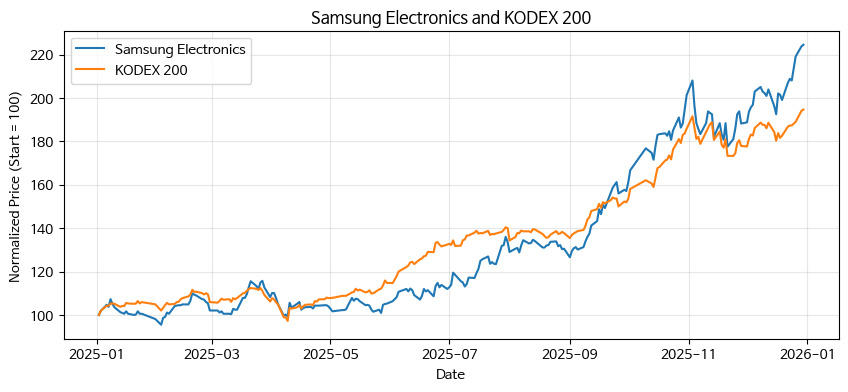

In [12]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(10, 4))

plt.plot(
    normalized.index,
    normalized["삼성전자"],
    label="Samsung Electronics"
)

plt.plot(
    normalized.index,
    normalized["KODEX200"],
    label="KODEX 200"
)

plt.title("Samsung Electronics and KODEX 200")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5. 일간수익률 계산

In [13]:
returns = df.pct_change(fill_method=None) * 100

returns = returns.dropna()

print(returns.head())

                삼성전자  KODEX200
날짜                            
2025-01-03  1.872659  2.000000
2025-01-06  2.757353  2.150232
2025-01-07 -0.894454  0.027819
2025-01-08  3.429603  0.961033
2025-01-09 -2.094241  0.073457


### 6. 산점도 확인

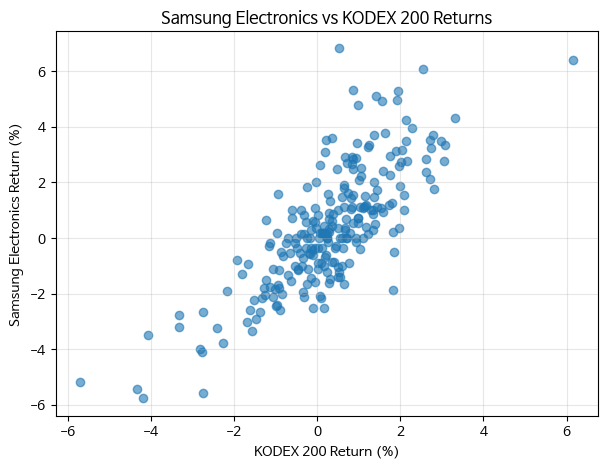

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(
    returns["KODEX200"],
    returns["삼성전자"],
    alpha=0.6
)

plt.title("Samsung Electronics vs KODEX 200 Returns")
plt.xlabel("KODEX 200 Return (%)")
plt.ylabel("Samsung Electronics Return (%)")
plt.grid(alpha=0.3)

plt.show()

### 7. 피어슨 상관계수

In [ ]:
# 피어슨 상관계수는 두 수익률의 선형관계를 측정합니다.

In [14]:
pearson_corr = returns["삼성전자"].corr(
    returns["KODEX200"],
    method="pearson"
)

print("피어슨 상관계수:", round(pearson_corr, 4))

피어슨 상관계수: 0.7794


### 8. 스피어만 상관계수

In [ ]:
#스피어만 상관계수는 수익률의 실제 크기 대신 순위관계를 측정합니다.

In [15]:
spearman_corr = returns["삼성전자"].corr(
    returns["KODEX200"],
    method="spearman"
)

print("스피어만 상관계수:", round(spearman_corr, 4))

스피어만 상관계수: 0.7616


In [16]:
print("피어슨 상관계수  :", round(pearson_corr, 4))
print("스피어만 상관계수:", round(spearman_corr, 4))

피어슨 상관계수  : 0.7794
스피어만 상관계수: 0.7616


### 9. 선형회귀모형 학습

In [ ]:
#독립변수는 KODEX 200 수익률, 종속변수는 삼성전자 수익률입니다.
# 삼성전자 수익률=β0+β1×KODEX 200 수익률+ϵ

In [18]:
X = returns[["KODEX200"]]
y = returns["삼성전자"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

### 10. 회귀계수 확인

In [19]:
beta_0 = model.intercept_
beta_1 = model.coef_[0]

print("절편 beta_0:", round(beta_0, 4))
print("회귀계수 beta_1:", round(beta_1, 4))

절편 beta_0: 0.0182
회귀계수 beta_1: 1.1897


In [ ]:
#예를 들어 회귀계수가 1.1897이면:
# KODEX 200 수익률이 1%p 상승할 때 삼성전자 수익률은 평균적으로 1.19%p 상승하는 경향이 있습니다.

### 11. 예측값과 성능 확인

In [20]:
y_pred = model.predict(X)

r_squared = r2_score(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

print("결정계수 R²:", round(r_squared, 4))
print("RMSE:", round(rmse, 4))

결정계수 R²: 0.6075
RMSE: 1.3557


In [ ]:
# 해석
# R2: KODEX 200 수익률이 삼성전자 수익률 변동을 설명하는 정도
# RMSE: 실제 수익률과 회귀모형 예측값의 평균적인 차이

### 12. 회귀선 시각화

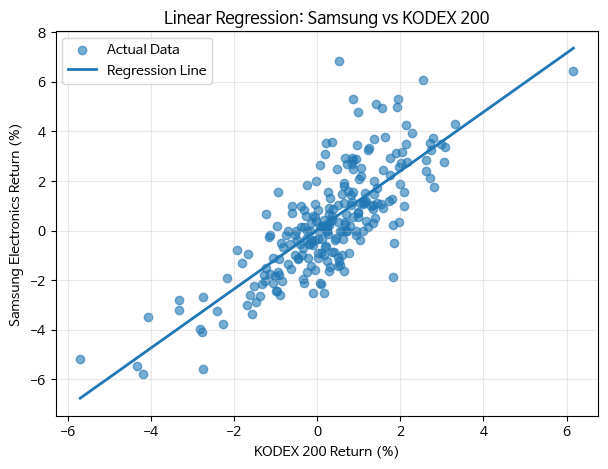

In [21]:
x_range = np.linspace(
    returns["KODEX200"].min(),
    returns["KODEX200"].max(),
    100
).reshape(-1, 1)

x_range_df = pd.DataFrame(
    x_range,
    columns=["KODEX200"]
)

regression_line = model.predict(x_range_df)

plt.figure(figsize=(7, 5))

plt.scatter(
    returns["KODEX200"],
    returns["삼성전자"],
    alpha=0.6,
    label="Actual Data"
)

plt.plot(
    x_range,
    regression_line,
    linewidth=2,
    label="Regression Line"
)

plt.title("Linear Regression: Samsung vs KODEX 200")
plt.xlabel("KODEX 200 Return (%)")
plt.ylabel("Samsung Electronics Return (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()